In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import lightgbm as lgb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [6]:
import os

FILENAME = "Churn_Modelling.csv"

if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        print("Please upload Churn_Modelling.csv")
        uploaded = files.upload()
        FILENAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Churn_Modelling.csv not found. Place it in the working directory."
        )

df = pd.read_csv(FILENAME)
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None ")

Columns with missing values:
None 


In [10]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate CustomerIds:", df['CustomerId'].duplicated().sum())


Duplicate rows: 0
Duplicate CustomerIds: 0


/tmp/ipykernel_4465/3357410646.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Exited", data=df, palette="Set2")


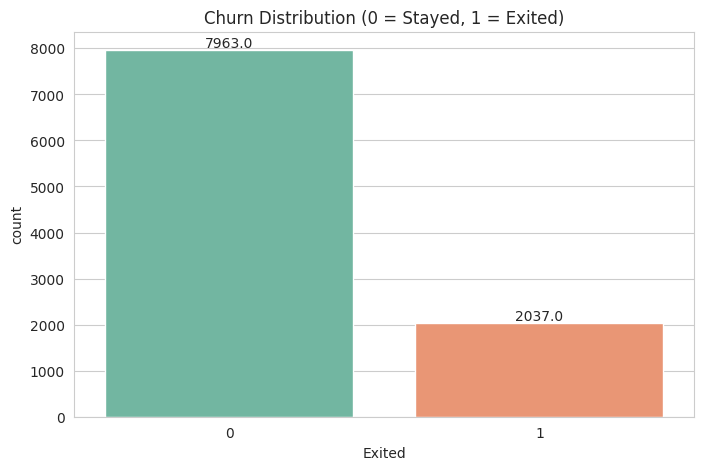

Exited
0    79.63 %
1    20.37 %
Name: proportion, dtype: object


In [11]:
ax = sns.countplot(x="Exited", data=df, palette="Set2")
ax.set_title("Churn Distribution (0 = Stayed, 1 = Exited)")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df["Exited"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")


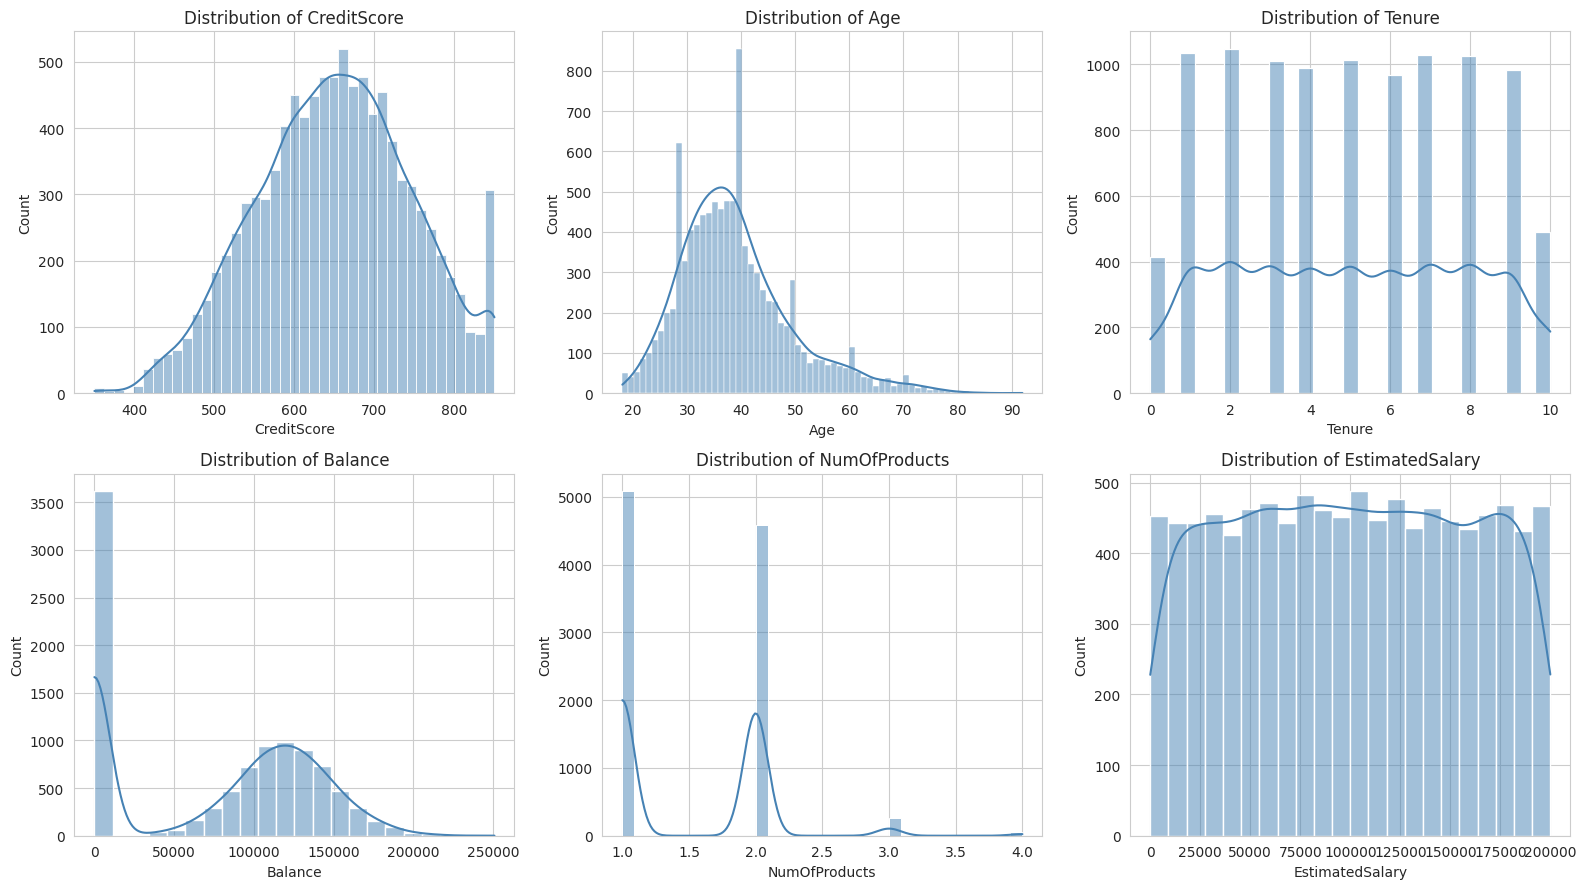

In [12]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


/tmp/ipykernel_4465/364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_4465/364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_4465/364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_4465/364394427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

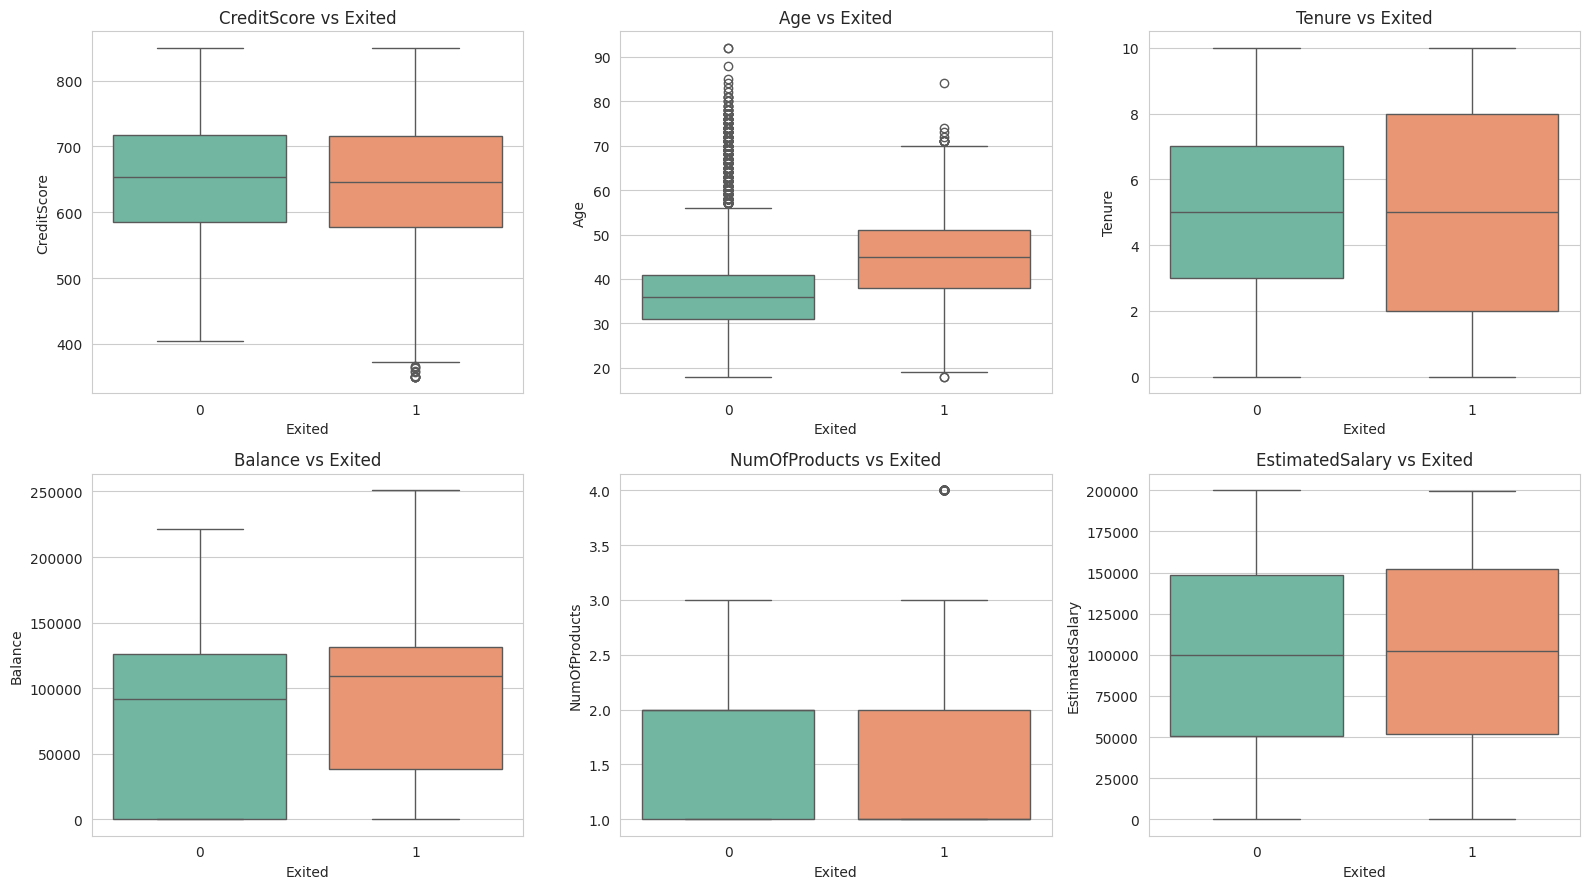

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Exited")
plt.tight_layout()
plt.show()


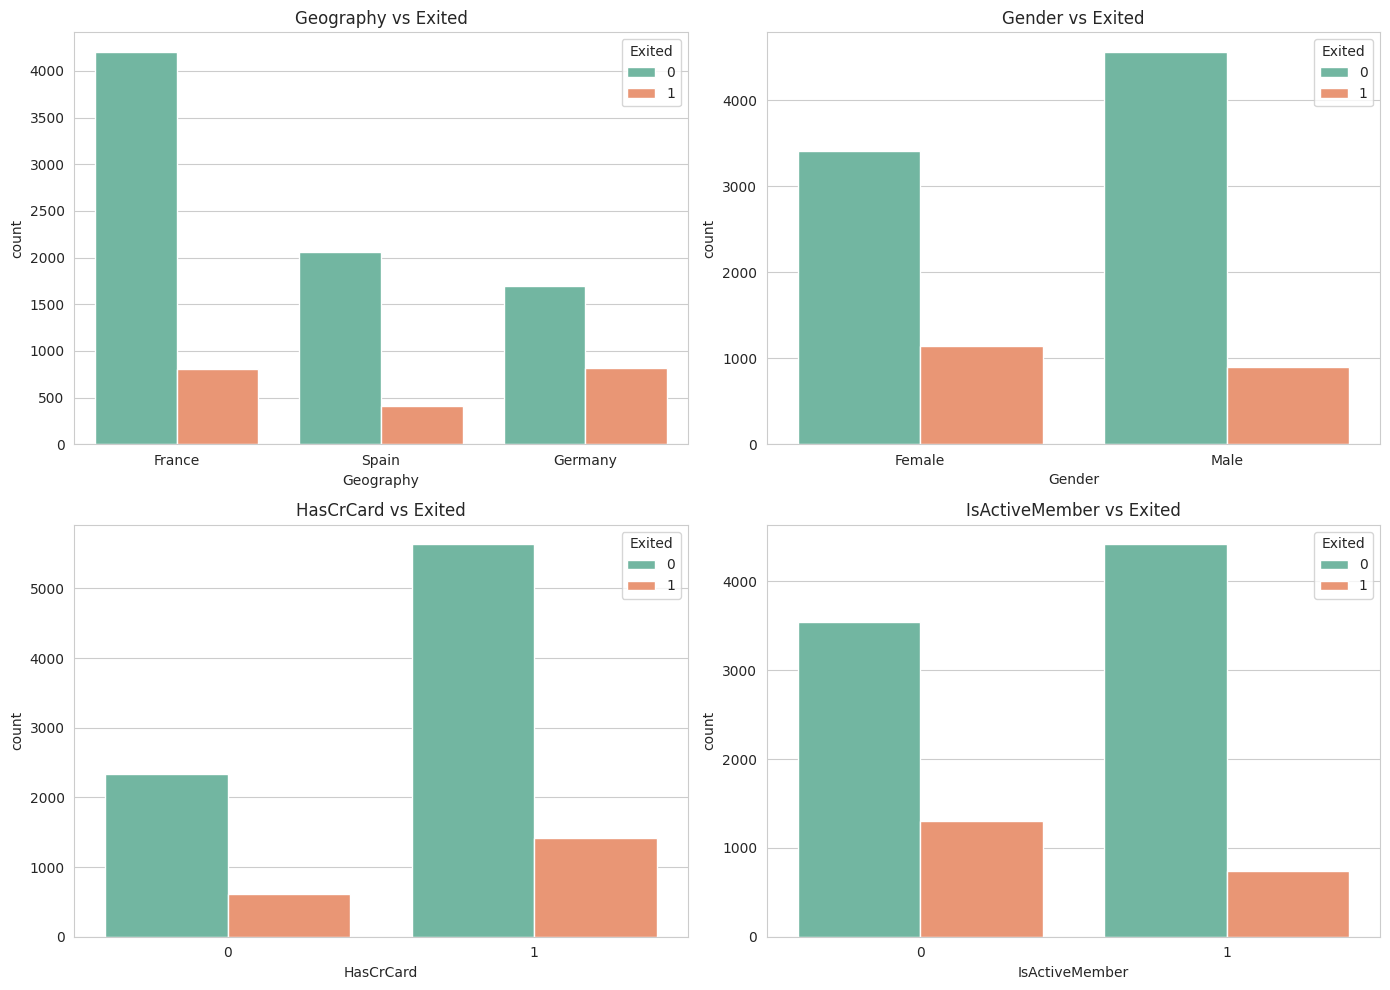

In [14]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, hue="Exited", data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Exited")
plt.tight_layout()
plt.show()


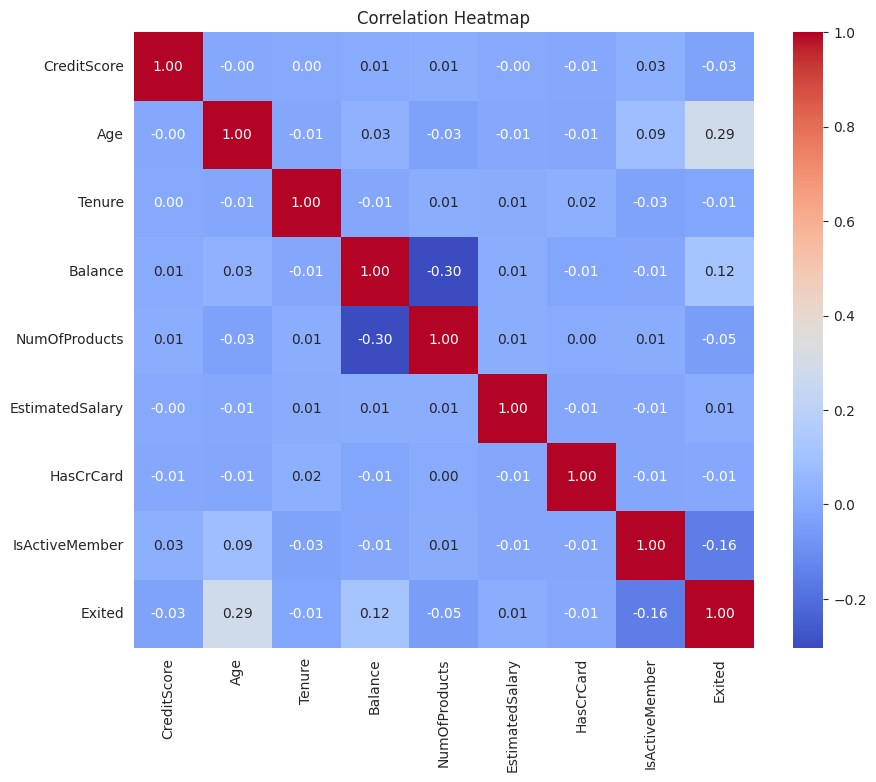

In [15]:
plt.figure(figsize=(10, 8))
corr_cols = num_cols + ["HasCrCard", "IsActiveMember", "Exited"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
data = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()

# Encode Gender (binary) with LabelEncoder
le_gender = LabelEncoder()
data["Gender"] = le_gender.fit_transform(data["Gender"])  # Female=0, Male=1

# One-hot encode Geography
data = pd.get_dummies(data, columns=["Geography"], drop_first=True)

data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [17]:
X = data.drop(columns=["Exited"])
y = data["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: %.2f%%" % (y_train.mean() * 100))
print("Test churn rate:  %.2f%%" % (y_test.mean() * 100))

Train shape: (8000, 11)  Test shape: (2000, 11)
Train churn rate: 20.38%
Test churn rate:  20.35%


In [18]:
# Scaled versions (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



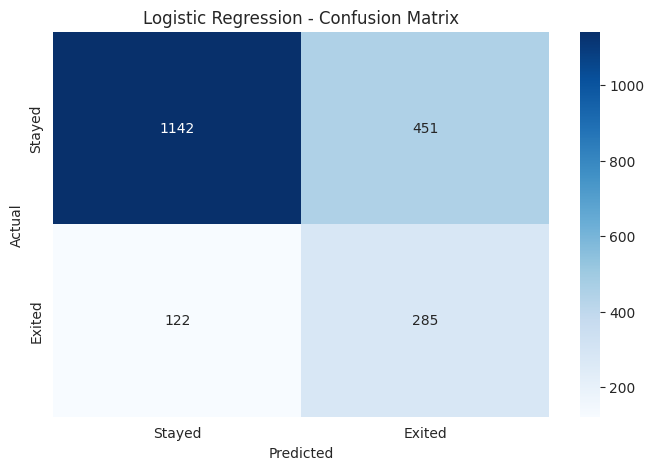

In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Exited"], yticklabels=["Stayed", "Exited"])
plt.title("Logistic Regression - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [21]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

lgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

y_pred_lgb = lgb_clf.predict(X_test)
y_proba_lgb = lgb_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgb))


              precision    recall  f1-score   support

           0       0.93      0.83      0.87      1593
           1       0.52      0.74      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.74      2000
weighted avg       0.84      0.81      0.82      2000



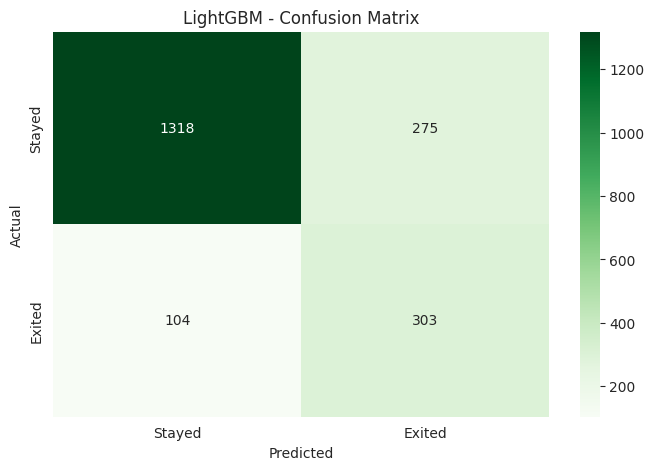

In [22]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Stayed", "Exited"], yticklabels=["Stayed", "Exited"])
plt.title("LightGBM - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


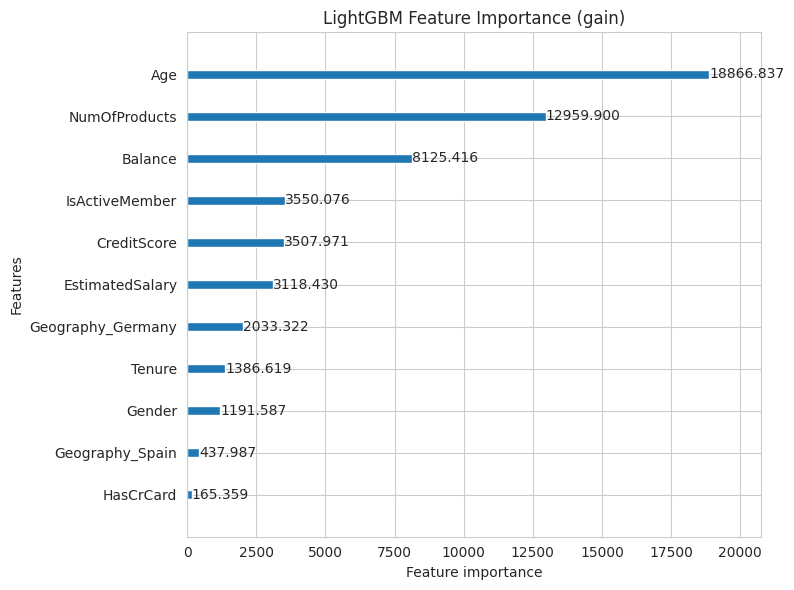

In [23]:
lgb.plot_importance(lgb_clf, max_num_features=15, importance_type="gain", figsize=(8,6))
plt.title("LightGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()


In [24]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    get_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    get_metrics("LightGBM", y_test, y_pred_lgb, y_proba_lgb),
]).set_index("Model").round(4)

results


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7771
LightGBM,0.8105,0.5242,0.7445,0.6152,0.8682


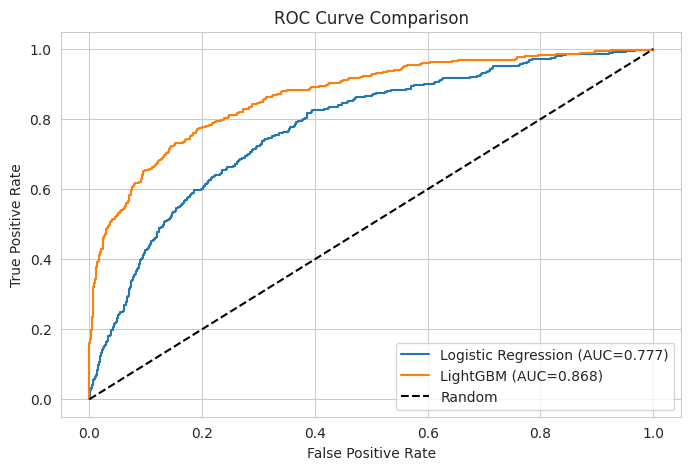

In [25]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={results.loc['Logistic Regression','ROC-AUC']:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={results.loc['LightGBM','ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()